# Limpieza de datos 
Este notebook tiene el propósito de documentar la limpieza del dataset dado por globant. Toma el dataset original y termina con una versión limpiada. La metodología sigue los siguientes pasos

1. Tratamiento de variables con valores nulos: se eliminan las variables con más de 7 valores nulos. Como el dataset tiene pocas observaciones y las variables de _Aceite Base_ y _Espesante_ son categóricas, se rellenaron los datos con "No especificados" para mantener los demás datos.   
2. Renombramiento de variables: se estandarizan los nombres de las columnas
3. Tratamiento de variables con datos especiales: 
    * Penetración de Cono a 25°C, 0.1mm: 
    * Punto de Gota, °C: Para los valores designados como "no gotea", se seleccionó un valor relativamente alto 350 °C, pero que no introduciera outliers grandes dentro del dataset. Siendo el valor más alto 304 °C, se elevó para hacer la distinción con grasas que gotean dentro de la prueba de medición y las que no.
    * Estabilidad Mecánica, %:
    * Carga Timken Ok, lb: 
    * Resistencia al Lavado por Agua a 80 °C %
4. Imputación de datos con mediana y regresión lineal
5. Guardado de dataset


In [353]:
import pandas as pd
import numpy as np

In [354]:
df = pd.read_csv("../data/datos_grasas_Tec.csv", encoding="latin-1")

In [355]:
df.head(1)

,idDatosGrasas,codigoGrasa,Aceite Base,Espesante,Grado NLGI Consistencia,Viscosidad del Aceite Base a 40ï¿½C. cSt,"Penetraciï¿½n de Cono a 25ï¿½C, 0.1mm","Punto de Gota, ï¿½C","Estabilidad Mecï¿½nica, %","Punto de Soldadura Cuatro Bolas, kgf",...,Factor de Velocidad,"Temperatura de Servicio ï¿½C, min","Temperatura de Servicio ï¿½C, max",categoria,subtitulo,descripcion,beneficios,aplicaciones,color,textura
0,1,Grasa_1,Semi-Sintetico,Complejo Sulfonato de Calcio,2.0,680.0,279,304,1.07,500.0,...,200000.0,5,220,Grasa,Grasa de servicio pesado para alta resistencia...,El producto es grasa lubricante de servicio pe...,Excelentes caracterÃ­sticas de resistencia al ...,Debido a su composiciÃ³n Ã³ptima de aceites de...,CafÃ©,Suave


In [356]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 41 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   idDatosGrasas                               51 non-null     int64  
 1   codigoGrasa                                 51 non-null     object 
 2   Aceite Base                                 47 non-null     object 
 3   Espesante                                   45 non-null     object 
 4   Grado NLGI Consistencia                     51 non-null     float64
 5   Viscosidad del Aceite Base a 40ï¿½C. cSt    50 non-null     float64
 6   Penetraciï¿½n de Cono a 25ï¿½C, 0.1mm       51 non-null     object 
 7   Punto de Gota, ï¿½C                         51 non-null     object 
 8   Estabilidad Mecï¿½nica, %                   48 non-null     object 
 9   Punto de Soldadura Cuatro Bolas, kgf        50 non-null     float64
 10  Desgaste Cuatro 

# 1. Tratamiento de variables con valores nulos

In [357]:
df.isna().sum()

idDatosGrasas                                  0
codigoGrasa                                    0
Aceite Base                                    4
Espesante                                      6
Grado NLGI Consistencia                        0
Viscosidad del Aceite Base a 40ï¿½C. cSt       1
Penetraciï¿½n de Cono a 25ï¿½C, 0.1mm          0
Punto de Gota, ï¿½C                            0
Estabilidad Mecï¿½nica, %                      3
Punto de Soldadura Cuatro Bolas, kgf           1
Desgaste Cuatro Bolas, mm                     24
Indice de Carga-Desgaste                      41
Carga Timken Ok, lb                            5
Resistencia al Lavado por Agua a 80ï¿½C, %     7
Corrion EMCOR                                 50
Corrosiï¿½n al Cobre                          35
Prueba FZG                                    51
Registro NSF                                  45
Solidos Totales, %                            51
Tamaï¿½o de Particula, ï¿½                    51
Bombeabilidad       

In [358]:
# Se elimina la columna duplicada de id
df = df.drop(columns=["codigoGrasa"])

# los valores con más de 7 datos nulos son eliminados
df = df.drop(columns = df.columns[df.isna().sum() > 7])

In [359]:
df["Aceite Base"] = df["Aceite Base"].fillna("No especificado")
df["Espesante"] = df["Espesante"].fillna("No especificado") 

In [360]:
# Se elimina esta variable porque solo tiene un dato y no presenta variabilidad u otras categorías
df["categoria"].value_counts()
df = df.drop(columns= ["categoria"])

# Renombramiento de variables

In [361]:
coluumnas = df.columns.to_list()
coluumnas

['idDatosGrasas',
 'Aceite Base',
 'Espesante',
 'Grado NLGI Consistencia',
 'Viscosidad del Aceite Base a 40ï¿½C. cSt',
 'Penetraciï¿½n de Cono a 25ï¿½C, 0.1mm',
 'Punto de Gota, ï¿½C',
 'Estabilidad Mecï¿½nica, %',
 'Punto de Soldadura Cuatro Bolas, kgf',
 'Carga Timken Ok, lb',
 'Resistencia al Lavado por Agua a 80ï¿½C, %',
 'Temperatura de Servicio ï¿½C, min',
 'Temperatura de Servicio ï¿½C, max',
 'subtitulo',
 'descripcion',
 'beneficios',
 'aplicaciones',
 'color',
 'textura']

In [362]:
df = df.rename(columns={
'idDatosGrasas': "idGrasas",
 'Viscosidad del Aceite Base a 40ï¿½C. cSt': "Viscosidad del Aceite Base a 40 °C",
 'Penetraciï¿½n de Cono a 25ï¿½C, 0.1mm': "Penetracion de Cono a 25 °C 0.1mm",
 'Punto de Gota, ï¿½C': "Punto de Gota °C",
 'Estabilidad Mecï¿½nica, %': "Estabilidad Mecanica %",
 'Resistencia al Lavado por Agua a 80ï¿½C, %': "Resistencia al Lavado por Agua a 80 °C %",
 'Temperatura de Servicio ï¿½C, min': "Temperatura de Servicio °C min",
 'Temperatura de Servicio ï¿½C, max': "Temperatura de Servicio °C max",
})

df.head(0)

,idGrasas,Aceite Base,Espesante,Grado NLGI Consistencia,Viscosidad del Aceite Base a 40 °C,Penetracion de Cono a 25 °C 0.1mm,Punto de Gota °C,Estabilidad Mecanica %,"Punto de Soldadura Cuatro Bolas, kgf","Carga Timken Ok, lb",Resistencia al Lavado por Agua a 80 °C %,Temperatura de Servicio °C min,Temperatura de Servicio °C max,subtitulo,descripcion,beneficios,aplicaciones,color,textura


# Tratamiento de variables con datos especiales

Grado NLGI Consistencia:

Los valores posibles son categóricos, en un rango común de 0 a 3; hay algunas grasas especializadas que toman valores un poco más altos, pero son extraños. Aún así, se tomarán en cuenta simplemente redondeando al entero más cercano


In [363]:
df["Grado NLGI Consistencia"].value_counts()

Grado NLGI Consistencia
2.0    20
1.0    11
1.5     7
0.0     7
3.0     5
1.2     1
Name: count, dtype: int64

In [364]:
df_copy = df["Grado NLGI Consistencia"].copy()
df["Grado NLGI Consistencia"] = df_copy.round().astype("Int64")

df["Grado NLGI Consistencia"].value_counts()

Grado NLGI Consistencia
2    27
1    12
0     7
3     5
Name: count, dtype: Int64

Penetracion de Cono a 25 °C 0.1mm

In [365]:
df_copy= df["Penetracion de Cono a 25 °C 0.1mm"].copy()

In [366]:

mini = []
maxi = []


for i in range(len(df_copy)):
    valor = str(df_copy[i])  
    
    if "-" in valor:
        partes = valor.split("-")  
        mini.append(float(partes[0].strip()))
        maxi.append(float(partes[1].strip()))
        
    else:
        num = float(valor.strip())
        mini.append(num)
        maxi.append(num)

df["Penetracion de Cono a 25 °C 0.1mm min"] = mini
df["Penetracion de Cono a 25 °C 0.1mm max"] = maxi

Punto de Gota, °C

In [367]:
df_copy= df["Punto de Gota °C"].copy()

In [368]:
gota = []

for i in range(len(df_copy)):
    valor = str(df_copy[i])  
    
    if ">" in valor:
        partes = valor.split(">")  
        gota.append(float(partes[1].strip()))
        
    elif "No Gotea" in valor:
        # Asumimos que "No Gotea" significa un punto de goteo muy alto, asignamos un valor arbitrario alto
        gota.append(350)
        
    else:
        num = float(valor.strip())
        gota.append(num)

df["Punto de Gota °C"] = gota

Estabilidad Mecanica %

In [369]:
df_copy = df["Estabilidad Mecanica %"].copy()

In [370]:
mini = []
maxi = []


for i in range(len(df_copy)):
    valor = str(df_copy[i])  
    
    if "<" in valor:
        partes = valor.split("<")  
        mini.append(float(0))
        maxi.append(float(partes[1].strip()))
        
    elif "No Gotea" in valor:
        mini.append(0)
        
    else:
        num = float(valor.strip())
        mini.append(num)
        maxi.append(num)

df["Estabilidad Mecánica % min"] = mini
df["Estabilidad Mecánica % max"] = maxi

Resistencia al Lavado por Agua a 80 °C %

In [371]:
df_copy = df["Resistencia al Lavado por Agua a 80 °C %"].copy()

In [372]:
mini = []
maxi = []


for i in range(len(df_copy)):
    valor = str(df_copy[i])  
    
    if "<" in valor:
        partes = valor.split("<")  
        mini.append(float(0))
        maxi.append(float(partes[1].strip()))
        
    else:
        num = float(valor.strip())
        mini.append(num)
        maxi.append(num)

df["Resistencia al Lavado por Agua a 80 °C % min"] = mini
df["Resistencia al Lavado por Agua a 80 °C % max"] = maxi

Eliminamos las columnas que fueron tratatas

In [373]:
df = df.drop(columns=["Penetracion de Cono a 25 °C 0.1mm",
                       "Estabilidad Mecanica %",
                          "Carga Timken Ok, lb",
                          "Resistencia al Lavado por Agua a 80 °C %"])
df.head(0)

,idGrasas,Aceite Base,Espesante,Grado NLGI Consistencia,Viscosidad del Aceite Base a 40 °C,Punto de Gota °C,"Punto de Soldadura Cuatro Bolas, kgf",Temperatura de Servicio °C min,Temperatura de Servicio °C max,subtitulo,...,beneficios,aplicaciones,color,textura,Penetracion de Cono a 25 °C 0.1mm min,Penetracion de Cono a 25 °C 0.1mm max,Estabilidad Mecánica % min,Estabilidad Mecánica % max,Resistencia al Lavado por Agua a 80 °C % min,Resistencia al Lavado por Agua a 80 °C % max


Ordenamos el dataframe en índice, variables numéricas y luego variables categóricas

In [374]:
num_variables = df.select_dtypes(include=["int64","float64"]).columns.to_list()
cat_variables = df.select_dtypes(include= ["O"]).columns.to_list()

columnas = num_variables + cat_variables
df = df[columnas]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 21 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   idGrasas                                      51 non-null     int64  
 1   Grado NLGI Consistencia                       51 non-null     Int64  
 2   Viscosidad del Aceite Base a 40 °C            50 non-null     float64
 3   Punto de Gota °C                              51 non-null     float64
 4   Punto de Soldadura Cuatro Bolas, kgf          50 non-null     float64
 5   Temperatura de Servicio °C min                51 non-null     int64  
 6   Temperatura de Servicio °C max                51 non-null     int64  
 7   Penetracion de Cono a 25 °C 0.1mm min         51 non-null     float64
 8   Penetracion de Cono a 25 °C 0.1mm max         51 non-null     float64
 9   Estabilidad Mecánica % min                    48 non-null     float

# Imputación de datos con mediana y regresión lineal

In [375]:
df.isna().sum()

idGrasas                                        0
Grado NLGI Consistencia                         0
Viscosidad del Aceite Base a 40 °C              1
Punto de Gota °C                                0
Punto de Soldadura Cuatro Bolas, kgf            1
Temperatura de Servicio °C min                  0
Temperatura de Servicio °C max                  0
Penetracion de Cono a 25 °C 0.1mm min           0
Penetracion de Cono a 25 °C 0.1mm max           0
Estabilidad Mecánica % min                      3
Estabilidad Mecánica % max                      3
Resistencia al Lavado por Agua a 80 °C % min    7
Resistencia al Lavado por Agua a 80 °C % max    7
Aceite Base                                     0
Espesante                                       0
subtitulo                                       0
descripcion                                     0
beneficios                                      0
aplicaciones                                    0
color                                           0


In [376]:
import seaborn as sns
import matplotlib.pyplot as plt

Revisamos la matriz de correlación y las distribuciones de las variables con su mediana y media

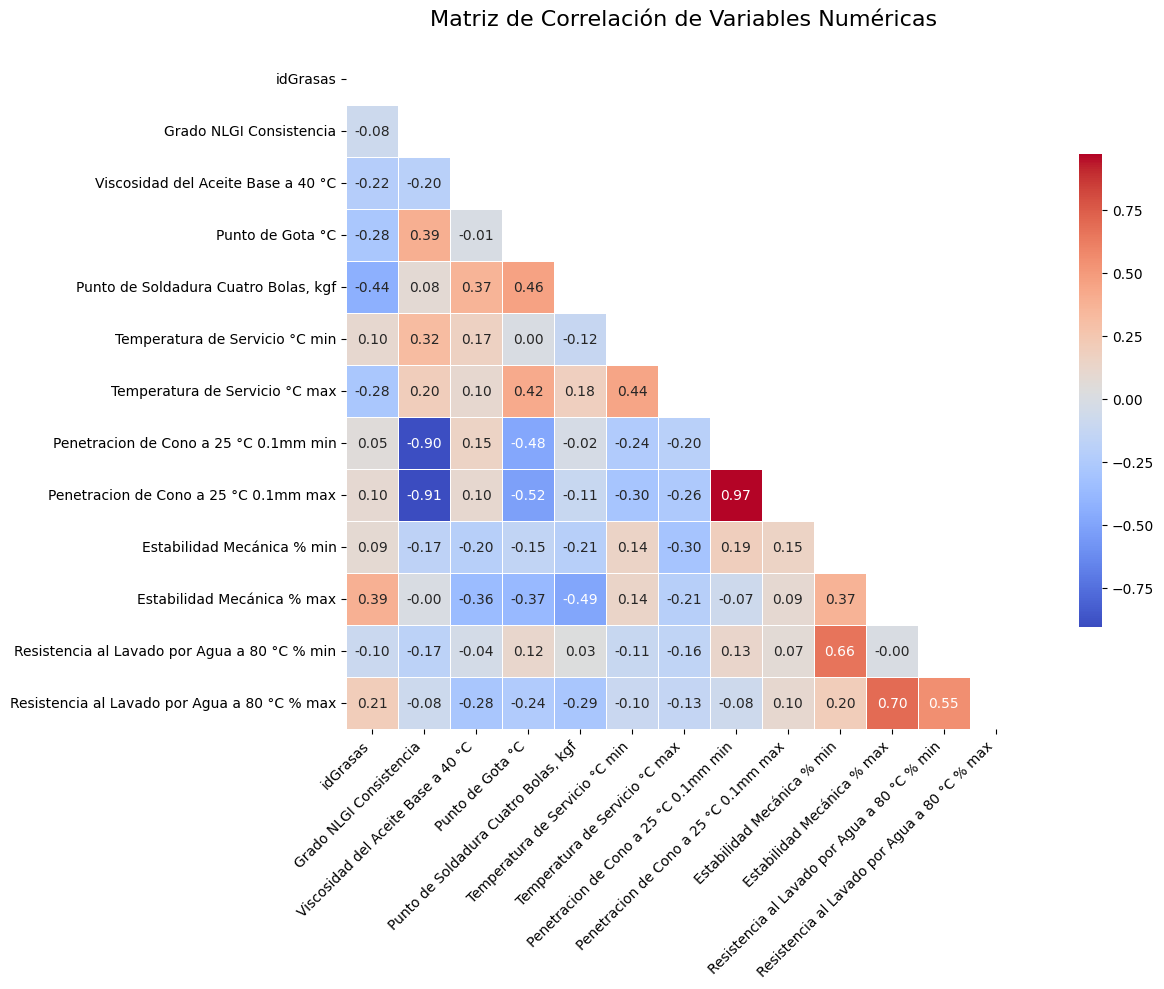

In [ ]:
df_num = df[num_variables]

corr = df_num.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,      # líneas divisorias
    linecolor="white",
    square=True,         # celdas cuadradas
    cbar_kws={"shrink": 0.7}
)

plt.title("Matriz de Correlación de Variables Numéricas", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

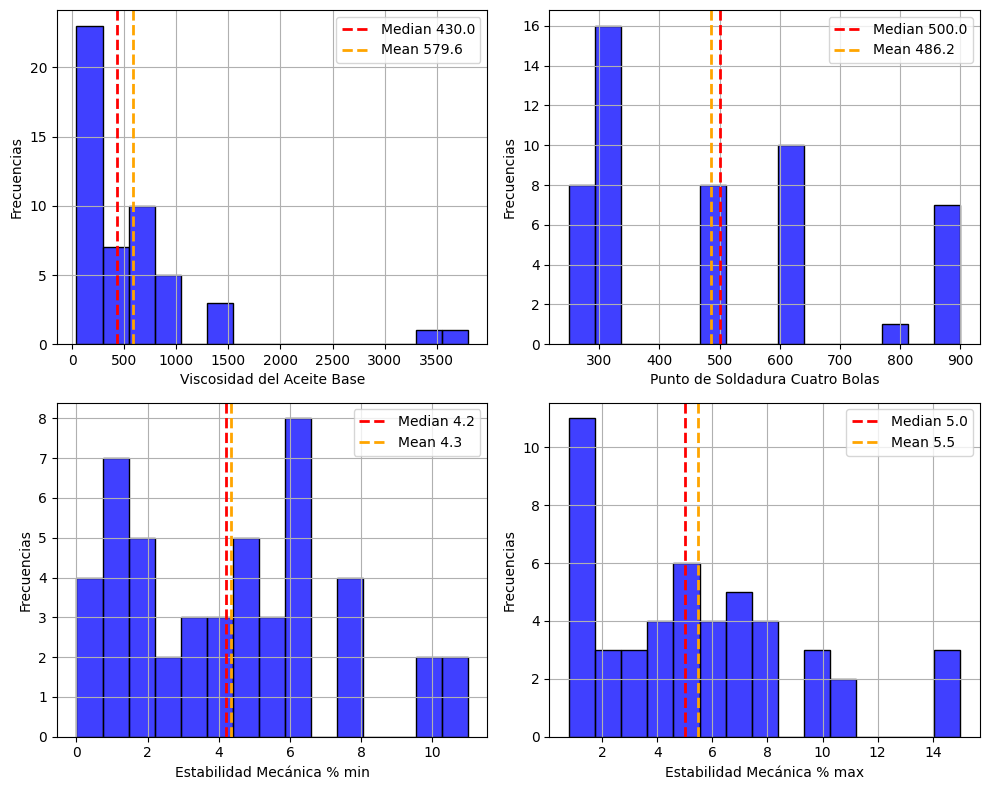

In [378]:
plt.figure(figsize=(10, 8))

plt.subplot(2,2,1)
sns.histplot(df["Viscosidad del Aceite Base a 40 °C"], bins=15, color="blue")
plt.axvline(df["Viscosidad del Aceite Base a 40 °C"].median(), color="red", linestyle="--", linewidth=2, label = f"Median {df["Viscosidad del Aceite Base a 40 °C"].median():.1f}")
plt.axvline(df["Viscosidad del Aceite Base a 40 °C"].mean(), color="orange", linestyle="--", linewidth=2, label = f"Mean {df["Viscosidad del Aceite Base a 40 °C"].mean():.1f}")
plt.legend()
plt.xlabel("Viscosidad del Aceite Base")
plt.ylabel("Frecuencias")
plt.grid()

plt.subplot(2,2,2)
sns.histplot(df["Punto de Soldadura Cuatro Bolas, kgf"], bins=15, color="blue")
plt.axvline(df["Punto de Soldadura Cuatro Bolas, kgf"].median(), color="red", linestyle="--", linewidth=2, label = f"Median {df["Punto de Soldadura Cuatro Bolas, kgf"].median():.1f}")
plt.axvline(df["Punto de Soldadura Cuatro Bolas, kgf"].mean(), color="orange", linestyle="--", linewidth=2, label = f"Mean {df["Punto de Soldadura Cuatro Bolas, kgf"].mean():.1f}")
plt.legend()
plt.xlabel("Punto de Soldadura Cuatro Bolas")
plt.ylabel("Frecuencias")
plt.grid()

plt.subplot(2,2,3)
sns.histplot(df["Estabilidad Mecánica % min"], bins=15, color="blue")
plt.axvline(df["Estabilidad Mecánica % min"].median(), color="red", linestyle="--", linewidth=2, label = f"Median {df["Estabilidad Mecánica % min"].median():.1f}")
plt.axvline(df["Estabilidad Mecánica % min"].mean(), color="orange", linestyle="--", linewidth=2, label = f"Mean {df["Estabilidad Mecánica % min"].mean():.1f}" )
plt.legend()
plt.xlabel("Estabilidad Mecánica % min")
plt.ylabel("Frecuencias")
plt.grid()

plt.subplot(2,2,4)
sns.histplot(df["Estabilidad Mecánica % max"], bins=15, color="blue")
plt.axvline(df["Estabilidad Mecánica % max"].median(), color="red", linestyle="--", linewidth=2, label = f"Median {df["Estabilidad Mecánica % max"].median():.1f}")
plt.axvline(df["Estabilidad Mecánica % max"].mean(), color="orange", linestyle="--", linewidth=2, label = f"Mean {df["Estabilidad Mecánica % max"].mean():.1f}")
plt.legend()
plt.xlabel("Estabilidad Mecánica % max")
plt.ylabel("Frecuencias")
plt.grid()

plt.tight_layout()
plt.show()


La mediana y el promedio están muy cerca en ambos casos dentro de las gráficas. Solamente la _Viscocidad del Aceite Base_ es la variable que difiere más entre mediana y media. Para los demás, son valores muy cercanos en decimales. Aún así, al ser pocos datos, se van a imputar rellenando con la mediana los valores faltantes, disminuyendo ligeramente el sesgo con esta estadística (la mediana)

In [379]:
df["Viscosidad del Aceite Base a 40 °C"] = df["Viscosidad del Aceite Base a 40 °C"].fillna(df["Viscosidad del Aceite Base a 40 °C"].median())
df["Punto de Soldadura Cuatro Bolas, kgf"] = df["Punto de Soldadura Cuatro Bolas, kgf"].fillna(df["Punto de Soldadura Cuatro Bolas, kgf"].median())
df["Estabilidad Mecánica % min"] = df["Estabilidad Mecánica % min"].fillna(df["Estabilidad Mecánica % min"].median())
df["Estabilidad Mecánica % max"] = df["Estabilidad Mecánica % max"].fillna(df["Estabilidad Mecánica % max"].median())

In [380]:
df.isna().sum()

idGrasas                                        0
Grado NLGI Consistencia                         0
Viscosidad del Aceite Base a 40 °C              0
Punto de Gota °C                                0
Punto de Soldadura Cuatro Bolas, kgf            0
Temperatura de Servicio °C min                  0
Temperatura de Servicio °C max                  0
Penetracion de Cono a 25 °C 0.1mm min           0
Penetracion de Cono a 25 °C 0.1mm max           0
Estabilidad Mecánica % min                      0
Estabilidad Mecánica % max                      0
Resistencia al Lavado por Agua a 80 °C % min    7
Resistencia al Lavado por Agua a 80 °C % max    7
Aceite Base                                     0
Espesante                                       0
subtitulo                                       0
descripcion                                     0
beneficios                                      0
aplicaciones                                    0
color                                           0


In [381]:
from sklearn.linear_model import LinearRegression

def imputar_regresion(df, target, features):
    df_copy = df.copy()

    # Filas con target conocido y features no nulos
    train = df_copy.dropna(subset=[target] + features)

    # No se puede entrenar si no hay suficientes datos
    if len(train) < 3:
        print(f"No hay suficientes datos para imputar {target}")
        return df_copy

    X_train = train[features]
    y_train = train[target]

    # Entrenar regresor
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Filas con target faltante pero features disponibles
    predict_rows = df_copy[df_copy[target].isna() & df_copy[features].notna().all(axis=1)]

    if len(predict_rows) == 0:
        print(f"No hay filas para predecir en {target}")
        return df_copy

    preds = model.predict(predict_rows[features])

    # Insertar predicciones
    df_copy.loc[predict_rows.index, target] = preds

    return df_copy

In [382]:
df = imputar_regresion(df, "Resistencia al Lavado por Agua a 80 °C % min", ["Estabilidad Mecánica % min"])
df = imputar_regresion(df, "Resistencia al Lavado por Agua a 80 °C % max", ["Estabilidad Mecánica % max"])

In [383]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 21 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   idGrasas                                      51 non-null     int64  
 1   Grado NLGI Consistencia                       51 non-null     Int64  
 2   Viscosidad del Aceite Base a 40 °C            51 non-null     float64
 3   Punto de Gota °C                              51 non-null     float64
 4   Punto de Soldadura Cuatro Bolas, kgf          51 non-null     float64
 5   Temperatura de Servicio °C min                51 non-null     int64  
 6   Temperatura de Servicio °C max                51 non-null     int64  
 7   Penetracion de Cono a 25 °C 0.1mm min         51 non-null     float64
 8   Penetracion de Cono a 25 °C 0.1mm max         51 non-null     float64
 9   Estabilidad Mecánica % min                    51 non-null     float

# Guardado de dataset

In [384]:
df.set_index("idGrasas", inplace=True)
df.to_csv("../data/dataset_limpio.csv") 

# Exploración de datos para Síntesis de nuevos datos (ampliar el dataset)

In [385]:
df = pd.read_csv("../data/dataset_limpio.csv")

Revisamos estadísticas generales

In [386]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
idGrasas,51.0,26.000000,14.866069,1.00,13.500000,26.0,38.5,51.0
Grado NLGI Consistencia,51.0,1.588235,0.852677,0.00,1.000000,2.0,2.0,3.0
Viscosidad del Aceite Base a 40 °C,51.0,576.666667,727.086423,40.00,120.000000,430.0,680.0,3800.0
Punto de Gota °C,51.0,268.862745,44.100349,110.00,252.500000,280.0,304.0,350.0
"Punto de Soldadura Cuatro Bolas, kgf",51.0,486.470588,219.263071,250.00,315.000000,500.0,620.0,900.0
Temperatura de Servicio °C min,51.0,-10.352941,8.941641,-30.00,-15.000000,-10.0,-5.0,5.0
Temperatura de Servicio °C max,51.0,153.529412,31.101352,90.00,150.000000,150.0,160.0,240.0
Penetracion de Cono a 25 °C 0.1mm min,51.0,297.588235,45.124794,220.00,270.000000,290.0,315.0,460.0
Penetracion de Cono a 25 °C 0.1mm max,51.0,302.745098,43.985836,230.00,275.000000,295.0,320.0,460.0
Estabilidad Mecánica % min,51.0,4.322941,2.966365,0.00,1.600000,4.2,6.4,11.0


Revisamos la mediana y moda de los datos

In [387]:
for col in num_variables:
    print(f"Mediana de {col}: {df[col].median()}")
    if col != "idGrasas":
        print(f"Moda de {col}: {df[col].mode()}")
    

Mediana de idGrasas: 26.0
Mediana de Grado NLGI Consistencia: 2.0
Moda de Grado NLGI Consistencia: 0    2
Name: Grado NLGI Consistencia, dtype: int64
Mediana de Viscosidad del Aceite Base a 40 °C: 430.0
Moda de Viscosidad del Aceite Base a 40 °C: 0    220.0
1    680.0
Name: Viscosidad del Aceite Base a 40 °C, dtype: float64
Mediana de Punto de Gota °C: 280.0
Moda de Punto de Gota °C: 0    304.0
Name: Punto de Gota °C, dtype: float64
Mediana de Punto de Soldadura Cuatro Bolas, kgf: 500.0
Moda de Punto de Soldadura Cuatro Bolas, kgf: 0    315.0
Name: Punto de Soldadura Cuatro Bolas, kgf, dtype: float64
Mediana de Temperatura de Servicio °C min: -10.0
Moda de Temperatura de Servicio °C min: 0   -5
Name: Temperatura de Servicio °C min, dtype: int64
Mediana de Temperatura de Servicio °C max: 150.0
Moda de Temperatura de Servicio °C max: 0    150
Name: Temperatura de Servicio °C max, dtype: int64
Mediana de Penetracion de Cono a 25 °C 0.1mm min: 290.0
Moda de Penetracion de Cono a 25 °C 0.1m

Revisamos con boxplots si existen muchos outliers. Esto con el fin de saber qué tipo de escalamiento es el correcto para los datos

In [388]:
import plotly.express as px

In [389]:
num_variables

['idGrasas',
 'Grado NLGI Consistencia',
 'Viscosidad del Aceite Base a 40 °C',
 'Punto de Gota °C',
 'Punto de Soldadura Cuatro Bolas, kgf',
 'Temperatura de Servicio °C min',
 'Temperatura de Servicio °C max',
 'Penetracion de Cono a 25 °C 0.1mm min',
 'Penetracion de Cono a 25 °C 0.1mm max',
 'Estabilidad Mecánica % min',
 'Estabilidad Mecánica % max',
 'Resistencia al Lavado por Agua a 80 °C % min',
 'Resistencia al Lavado por Agua a 80 °C % max']

In [390]:
# por cada variable, hacemos un boxplot para ver su distribución y posibles outliers
for col in num_variables:
    # mejoramos el formato y tamaño
    
    fig = px.box(df, y=col, title=f"Boxplot de {col}", width=600, height=400)
    fig.show()

In [391]:
# detección de outliers con el método IQR
outliers = {}
for col in num_variables:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_indices = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index.tolist()
    outliers[col] = outlier_indices
    
print("Outliers detectados por variable:")
for col, indices in outliers.items():
    print(f"{col}: {indices}")

Outliers detectados por variable:
idGrasas: []
Grado NLGI Consistencia: []
Viscosidad del Aceite Base a 40 °C: [6, 28]
Punto de Gota °C: [20, 28]
Punto de Soldadura Cuatro Bolas, kgf: []
Temperatura de Servicio °C min: []
Temperatura de Servicio °C max: [0, 6, 12, 13, 16, 17, 18, 26, 27, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45]
Penetracion de Cono a 25 °C 0.1mm min: [20, 33]
Penetracion de Cono a 25 °C 0.1mm max: [20, 33]
Estabilidad Mecánica % min: []
Estabilidad Mecánica % max: [46, 47, 48]
Resistencia al Lavado por Agua a 80 °C % min: []
Resistencia al Lavado por Agua a 80 °C % max: []
